# Segment Anything Model (SAM)
## Интерактивная сегментация одним кликом

### План семинара:
1. Что такое SAM
2. Сегментация по точкам (point prompts)
3. Сегментация по боксам (box prompts)
4. Сегментация всего на изображении (automatic mask generation)
5. Комбинация промптов
6. Практическое применение

SAM: Модель обучена на 11 млн изображений и может сегментировать ЛЮБОЙ объект по простому указанию (клик, бокс, текст)!


In [1]:
# Установка библиотек
# !pip install -q segment-anything opencv-python matplotlib numpy torch torchvision
from pathlib import Path
from huggingface_hub import hf_hub_download

checkpoint_path = Path("checkpoints/sam_vit_b_01ec64.pth")
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
if not checkpoint_path.exists():
    hf_hub_download("ybelkada/segment-anything", "checkpoints/sam_vit_b_01ec64.pth", local_dir="")

print(f"✅ Библиотеки готовы, checkpoint: {checkpoint_path}")

✅ Библиотеки готовы, checkpoint: checkpoints/sam_vit_b_01ec64.pth


/home/eugen/coding/thesis/experiments/satlas-super-resolution/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Импорт и настройка
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from segment_anything import SamPredictor, sam_model_registry, SamAutomaticMaskGenerator
from pathlib import Path
import requests
from PIL import Image
import io

# Настройка визуализации
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✅ Готово к работе!")

✅ Готово к работе!


## 1. Загрузка модели и изображения

In [3]:
# Инициализация SAM
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥 Используем: {device}")

# Регистрируем модель (доступные: vit_h, vit_l, vit_b)
sam = sam_model_registry["vit_b"](checkpoint="checkpoints/sam_vit_b_01ec64.pth")
sam.to(device=device)
predictor = SamPredictor(sam)

print(f"✅ SAM загружен на {device}")

🖥 Используем: cuda
✅ SAM загружен на cuda


Размер изображения: (1200, 1800, 3)


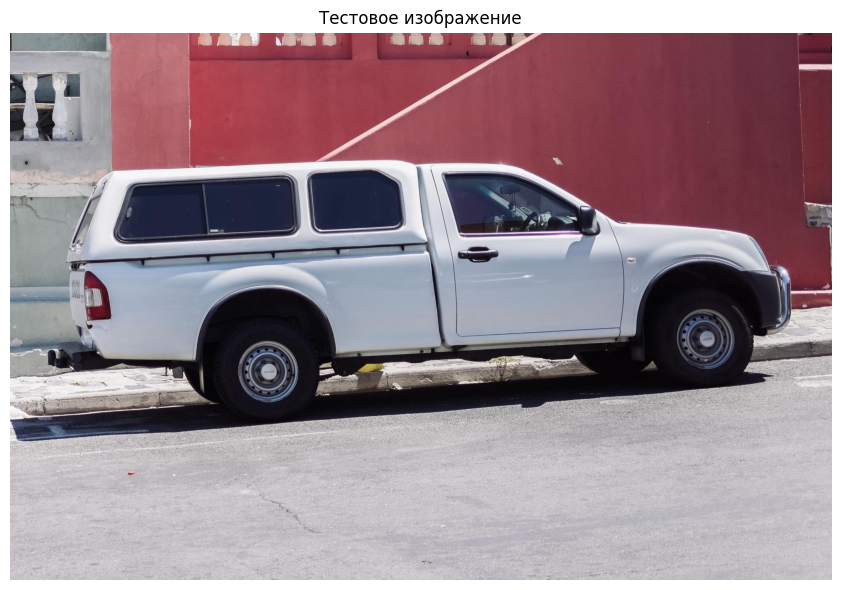

In [4]:
# Загружаем тестовое изображение
# Можно заменить на свое: image = cv2.imread("path/to/image.jpg")

image = np.array(Image.open("truck.jpg").convert("RGB"))

# Или загрузить свое изображение:
# image = cv2.imread("your_image.jpg")
# image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(f"Размер изображения: {image.shape}")

plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Тестовое изображение")
plt.tight_layout()
plt.show()

In [5]:
# Устанавливаем изображение в predictor (это нужно сделать один раз)
predictor.set_image(image)
print("✅ Изображение установлено в модель")

✅ Изображение установлено в модель


## 2. Сегментация по ТОЧКАМ (Point Prompts)

### Задание 2.1: Сегментация объекта по одной точке

Укажите координаты точки (x, y) внутри объекта, который хотите выделить.

Найдено масок: 3
Scores: [0.9052552 0.9511549 0.9838548]


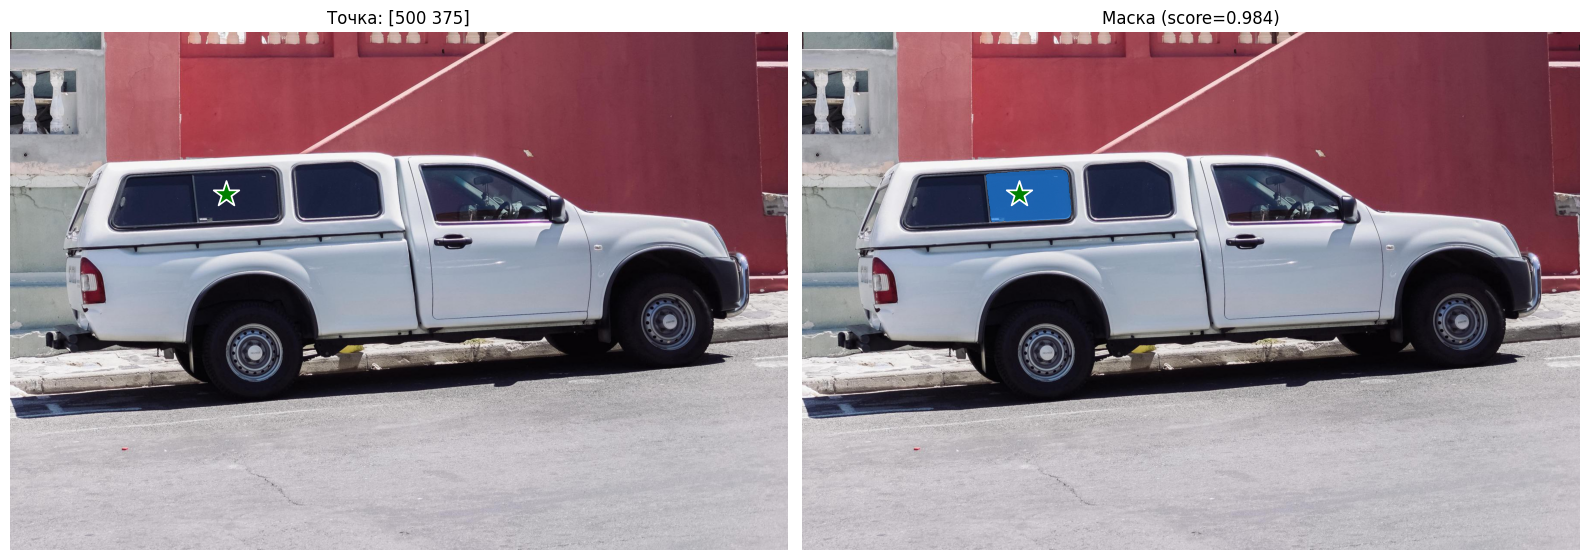

In [6]:
# Задаем точку (координаты x, y)
# Например, для грузовика: колесо, кабина, фара
input_point = np.array([[500, 375]])  # Координаты точки [x, y]
input_label = np.array([1])  # 1 = объект, 0 = фон

# Предсказание
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True  # Вернуть несколько вариантов
)

print(f"Найдено масок: {len(masks)}")
print(f"Scores: {scores}")

# Визуализация лучшей маски
best_mask_idx = np.argmax(scores)

def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], c='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], c='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].imshow(image)
show_points(input_point, input_label, ax[0])
ax[0].set_title(f"Точка: {input_point[0]}", fontsize=12)
ax[0].axis("off")

ax[1].imshow(image)
show_mask(masks[best_mask_idx], ax[1])
show_points(input_point, input_label, ax[1])
ax[1].set_title(f"Маска (score={scores[best_mask_idx]:.3f})", fontsize=12)
ax[1].axis("off")

plt.tight_layout()
plt.show()

### 📝 Задание 2.2: Эксперимент с точками

Попробуйте:
1. Сегментировать колесо грузовика (поставьте точку на колесе)
2. Сегментировать кабину (точка на кабине)
3. Сегментировать фару (точка на фаре)
4. Попробуйте указать точку фона (label=0) и посмотрите, что произойдет

Вопросы для размышления:**
- Почему иногда SAM выдает несколько масок для одной точки?
- Как меняется результат в зависимости от расположения точки?

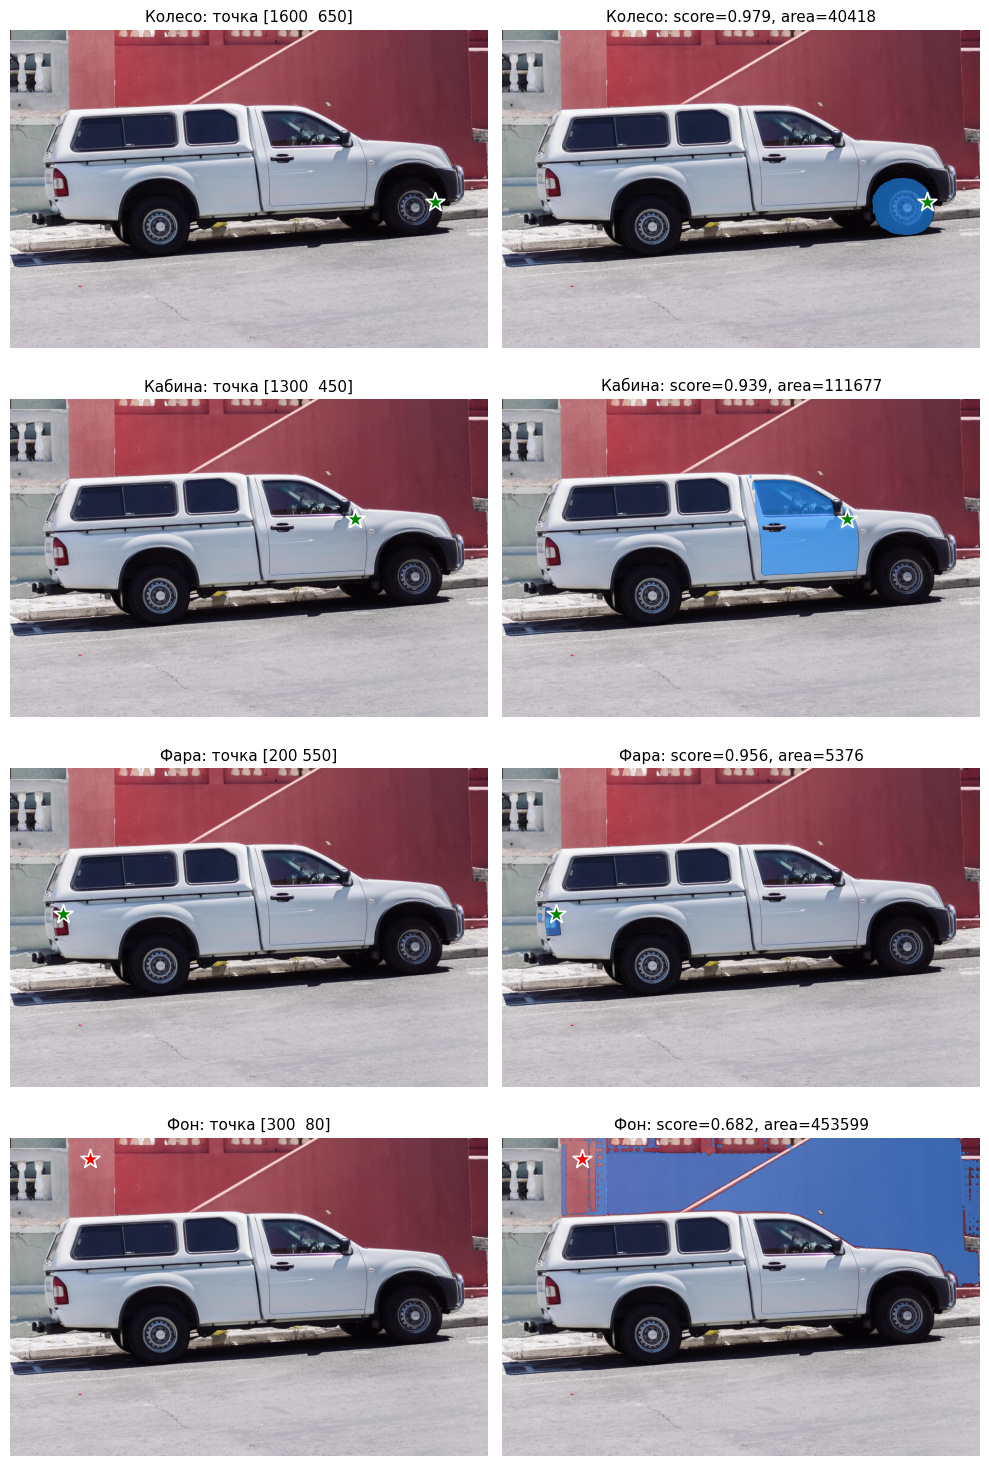

In [19]:
test_points = {
    "Колесо": np.array([[1600, 650]]),
    "Кабина": np.array([[1300, 450]]),
    "Фара": np.array([[200, 550]]),
    "Фон": np.array([[300, 80]]),
}

fig, axes = plt.subplots(4, 2, figsize=(10, 15))
axes = axes.ravel()

results_22 = []

for idx, (name, point) in enumerate(test_points.items()):
    label = np.array([1]) if name != "Фон" else np.array([0])

    masks, scores, _ = predictor.predict(
        point_coords=point,
        point_labels=label,
        multimask_output=True
    )

    best_idx = np.argmax(scores)
    best_mask = masks[best_idx]
    best_score = float(scores[best_idx])
    best_area = int(best_mask.sum())

    results_22.append({
        "target": name,
        "point": point[0].tolist(),
        "score": best_score,
        "area_px": best_area,
    })

    axes[2 * idx].imshow(image)
    show_points(point, label, axes[2 * idx], marker_size=200)
    axes[2 * idx].set_title(f"{name}: точка {point[0]}", fontsize=11)
    axes[2 * idx].axis("off")

    axes[2 * idx + 1].imshow(image)
    show_mask(best_mask, axes[2 * idx + 1])
    show_points(point, label, axes[2 * idx + 1], marker_size=200)
    axes[2 * idx + 1].set_title(
        f"{name}: score={best_score:.3f}, area={best_area}",
        fontsize=11
    )
    axes[2 * idx + 1].axis("off")

plt.tight_layout()
plt.show()

## 3. Сегментация по БОКСАМ (Box Prompts)

### Задание 3.1: Сегментация по bounding box

Задайте прямоугольник [x1, y1, x2, y2] вокруг объекта.

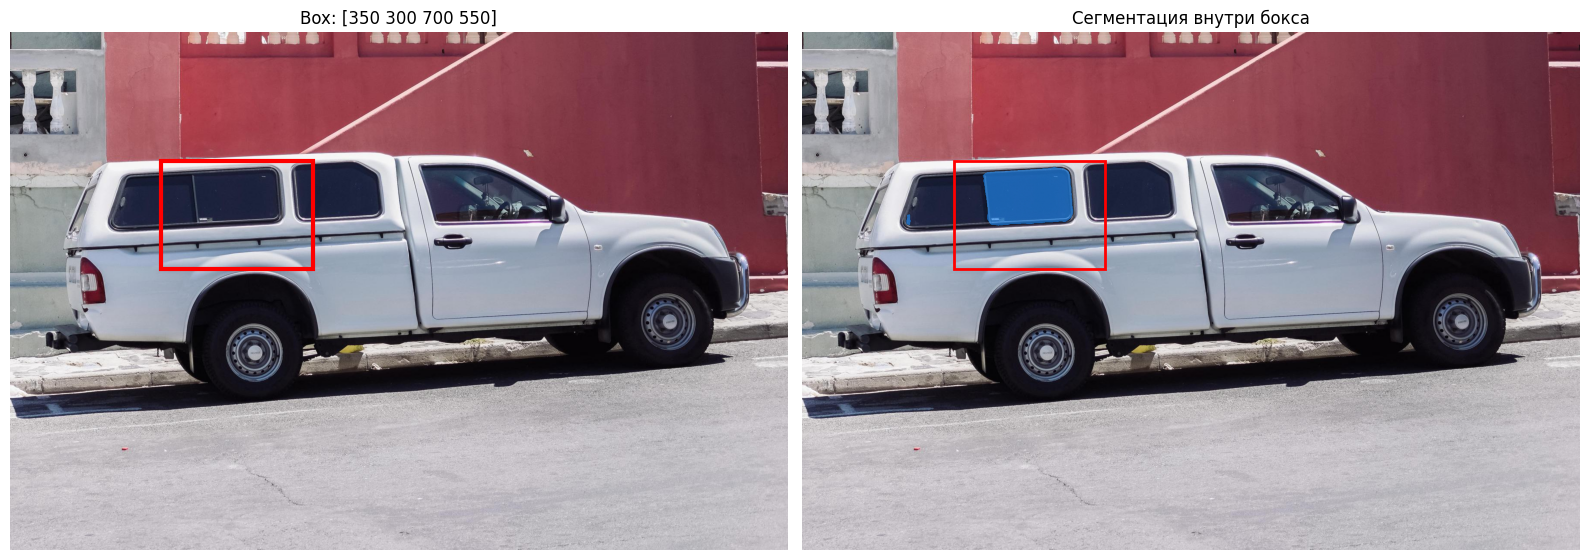

In [20]:
# Задаем bounding box [x1, y1, x2, y2]
input_box = np.array([350, 300, 700, 550])  # Пример: весь грузовик

# Предсказание
masks, scores, logits = predictor.predict(
    box=input_box[None, :],  # Добавляем размерность
    multimask_output=False
)

# Визуализация
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].imshow(image)
ax[0].add_patch(plt.Rectangle((input_box[0], input_box[1]), 
                               input_box[2]-input_box[0], 
                               input_box[3]-input_box[1],
                               fill=False, edgecolor='red', linewidth=3))
ax[0].set_title(f"Box: {input_box}", fontsize=12)
ax[0].axis("off")

ax[1].imshow(image)
show_mask(masks[0], ax[1])
ax[1].add_patch(plt.Rectangle((input_box[0], input_box[1]), 
                               input_box[2]-input_box[0], 
                               input_box[3]-input_box[1],
                               fill=False, edgecolor='red', linewidth=2))
ax[1].set_title("Сегментация внутри бокса", fontsize=12)
ax[1].axis("off")

plt.tight_layout()
plt.show()

### Задание 3.2: Сегментация нескольких объектов

Попробуйте задать несколько боксов для разных объектов одновременно!

📊 Найдено масок: 2


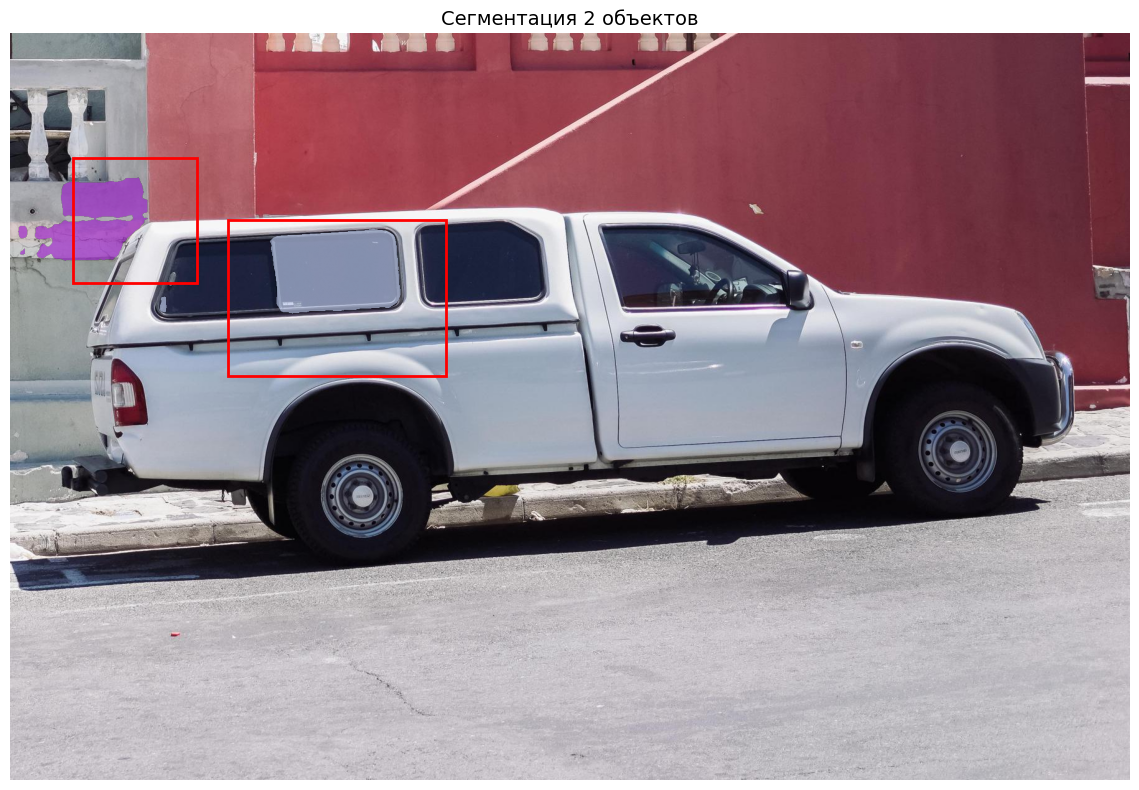

In [21]:
# 📦 Несколько боксов — вызываем predict для каждого отдельно
input_boxes = np.array([
    [350, 300, 700, 550],  # Грузовик
    [100, 200, 300, 400],  # Что-то еще на изображении
], dtype=np.float32)  # Важно: float32!

all_masks = []
all_scores = []

for box in input_boxes:
    masks, scores, logits = predictor.predict(
        box=box[None, :],  # Добавляем измерение батча (1, 4)
        multimask_output=False
    )
    all_masks.append(masks[0])
    all_scores.append(scores[0])

print(f"📊 Найдено масок: {len(all_masks)}")

# Визуализация
plt.figure(figsize=(12, 8))
plt.imshow(image)

for i, (mask, box) in enumerate(zip(all_masks, input_boxes)):
    show_mask(mask, plt.gca(), random_color=True)
    plt.gca().add_patch(plt.Rectangle((box[0], box[1]), 
                                       box[2]-box[0], box[3]-box[1],
                                       fill=False, edgecolor='red', linewidth=2))

plt.title(f"Сегментация {len(all_masks)} объектов", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Автоматическая сегментация ВСЕГО (Automatic Mask Generation)

SAM может автоматически найти ВСЕ объекты на изображении без каких-либо промптов!

In [22]:
# Создаем автоматический генератор масок
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,  # Сколько точек генерировать на сторону (больше = точнее, но медленнее)
    pred_iou_thresh=0.86,  # Порог качества масок (0-1)
    stability_score_thresh=0.92,  # Порог стабильности
    crop_n_layers=1,  # Сколько слоев кропа использовать
    crop_n_points_downscale_factor=2,
    min_mask_region_area=100,  # Минимальная площадь маски
)

print("✅ Генератор создан")

✅ Генератор создан


In [ ]:
# Генерируем все маски (это может занять 10-30 секунд)
print("Генерируем маски...")
masks_auto = mask_generator.generate(image)

print(f"Найдено объектов: {len(masks_auto)}")
print(f"Средняя площадь маски: {np.mean([m['area'] for m in masks_auto]):.0f} пикселей")

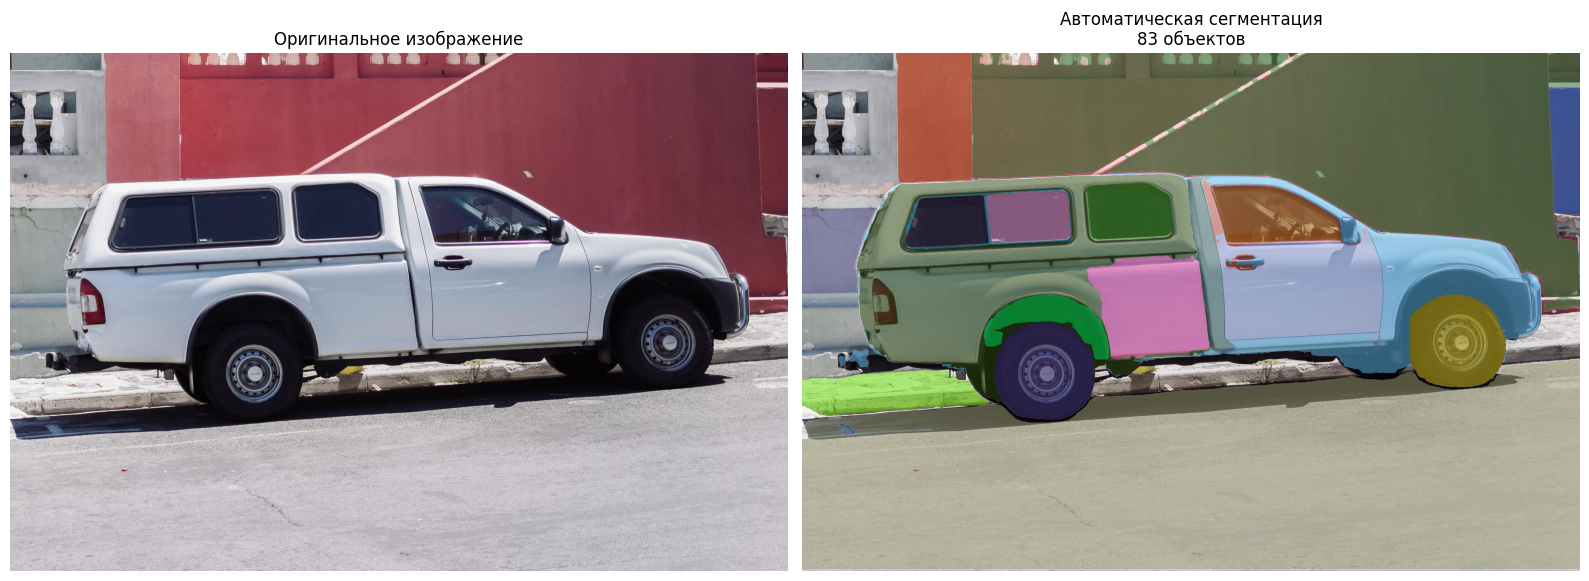

In [29]:
# Визуализация всех масок
def show_anns(anns, ax):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    
    ax.set_autoscale_on(False)
    img = np.ones((sorted_anns[0]['segmentation'].shape[0], 
                   sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    
    for ann in sorted_anns[:20]:  # Показываем топ-20 по площади
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask
    
    ax.imshow(img)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].imshow(image)
ax[0].set_title("Оригинальное изображение", fontsize=12)
ax[0].axis("off")

ax[1].imshow(image)
show_anns(masks_auto, ax[1])
ax[1].set_title(f"Автоматическая сегментация\n{len(masks_auto)} объектов", fontsize=12)
ax[1].axis("off")

plt.tight_layout()
plt.show()

### Задание 4.1: Анализ автоматической сегментации

Попробуйте изменить параметры генератора:
1. `points_per_side=16` (быстрее, но менее точно)
2. `points_per_side=64` (медленнее, но детальнее)
3. `pred_iou_thresh=0.5` (больше масок, но больше шума)
4. `pred_iou_thresh=0.95` (только очень качественные маски)

Сравните количество и качество масок!

## 5. Практическое применение: Интерактивная сегментация

### Задание 5.1: Выделение объекта интереса

Представьте, что вы разрабатываете инструмент для дизайнеров. Пользователь кликает на объект, а SAM его выделяет.

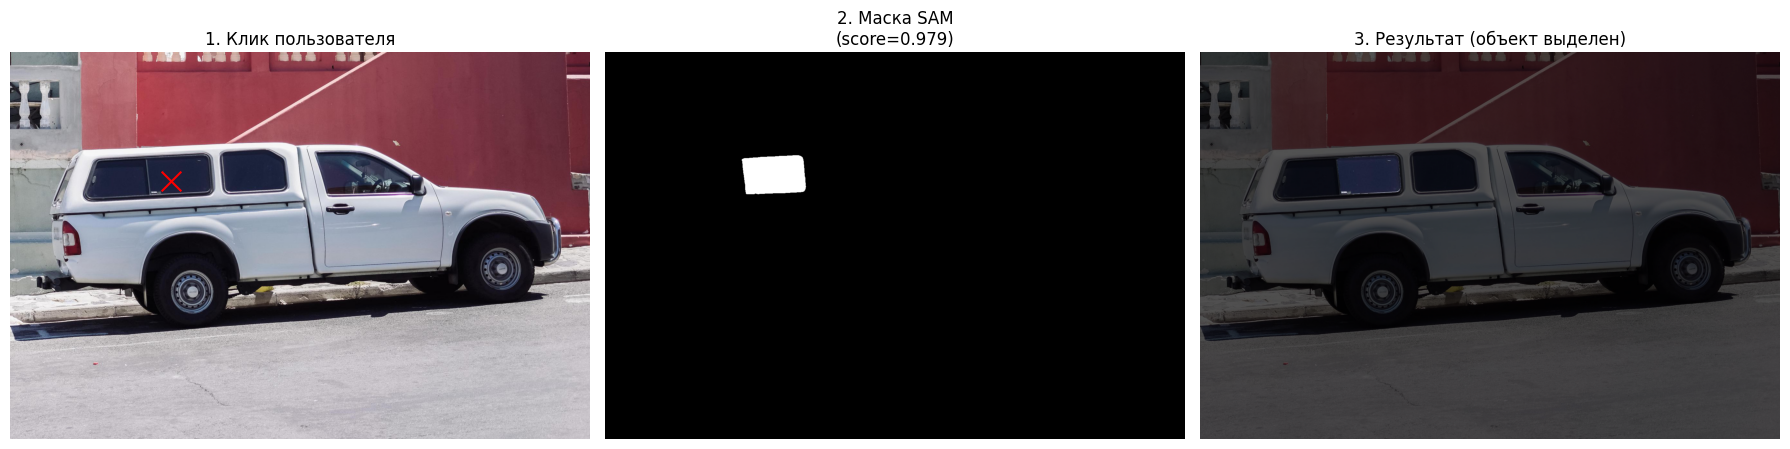

✅ Объект выделен! Площадь: 21535 пикселей


In [30]:
# Сценарий: Пользователь кликает на объект
# Симулируем клик пользователя (задайте координаты)
user_click = np.array([[500, 400]])  # Где кликнул пользователь
user_label = np.array([1])  # 1 = хочу выделить этот объект

# SAM находит объект
masks, scores, logits = predictor.predict(
    point_coords=user_click,
    point_labels=user_label,
    multimask_output=True
)

# Выбираем лучшую маску
best_idx = np.argmax(scores)
best_mask = masks[best_idx]

# Создаем маску для применения фильтров
masked_image = image.copy()
masked_image[~best_mask] = masked_image[~best_mask] // 3  # Затемняем фон

# Визуализация
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(image)
ax[0].scatter(user_click[:, 0], user_click[:, 1], c='red', s=200, marker='x')
ax[0].set_title("1. Клик пользователя", fontsize=12)
ax[0].axis("off")

ax[1].imshow(best_mask, cmap='gray')
ax[1].set_title(f"2. Маска SAM\n(score={scores[best_idx]:.3f})", fontsize=12)
ax[1].axis("off")

ax[2].imshow(masked_image)
ax[2].set_title("3. Результат (объект выделен)", fontsize=12)
ax[2].axis("off")

plt.tight_layout()
plt.show()

print(f"✅ Объект выделен! Площадь: {np.sum(best_mask)} пикселей")

## 6. Сравнение методов

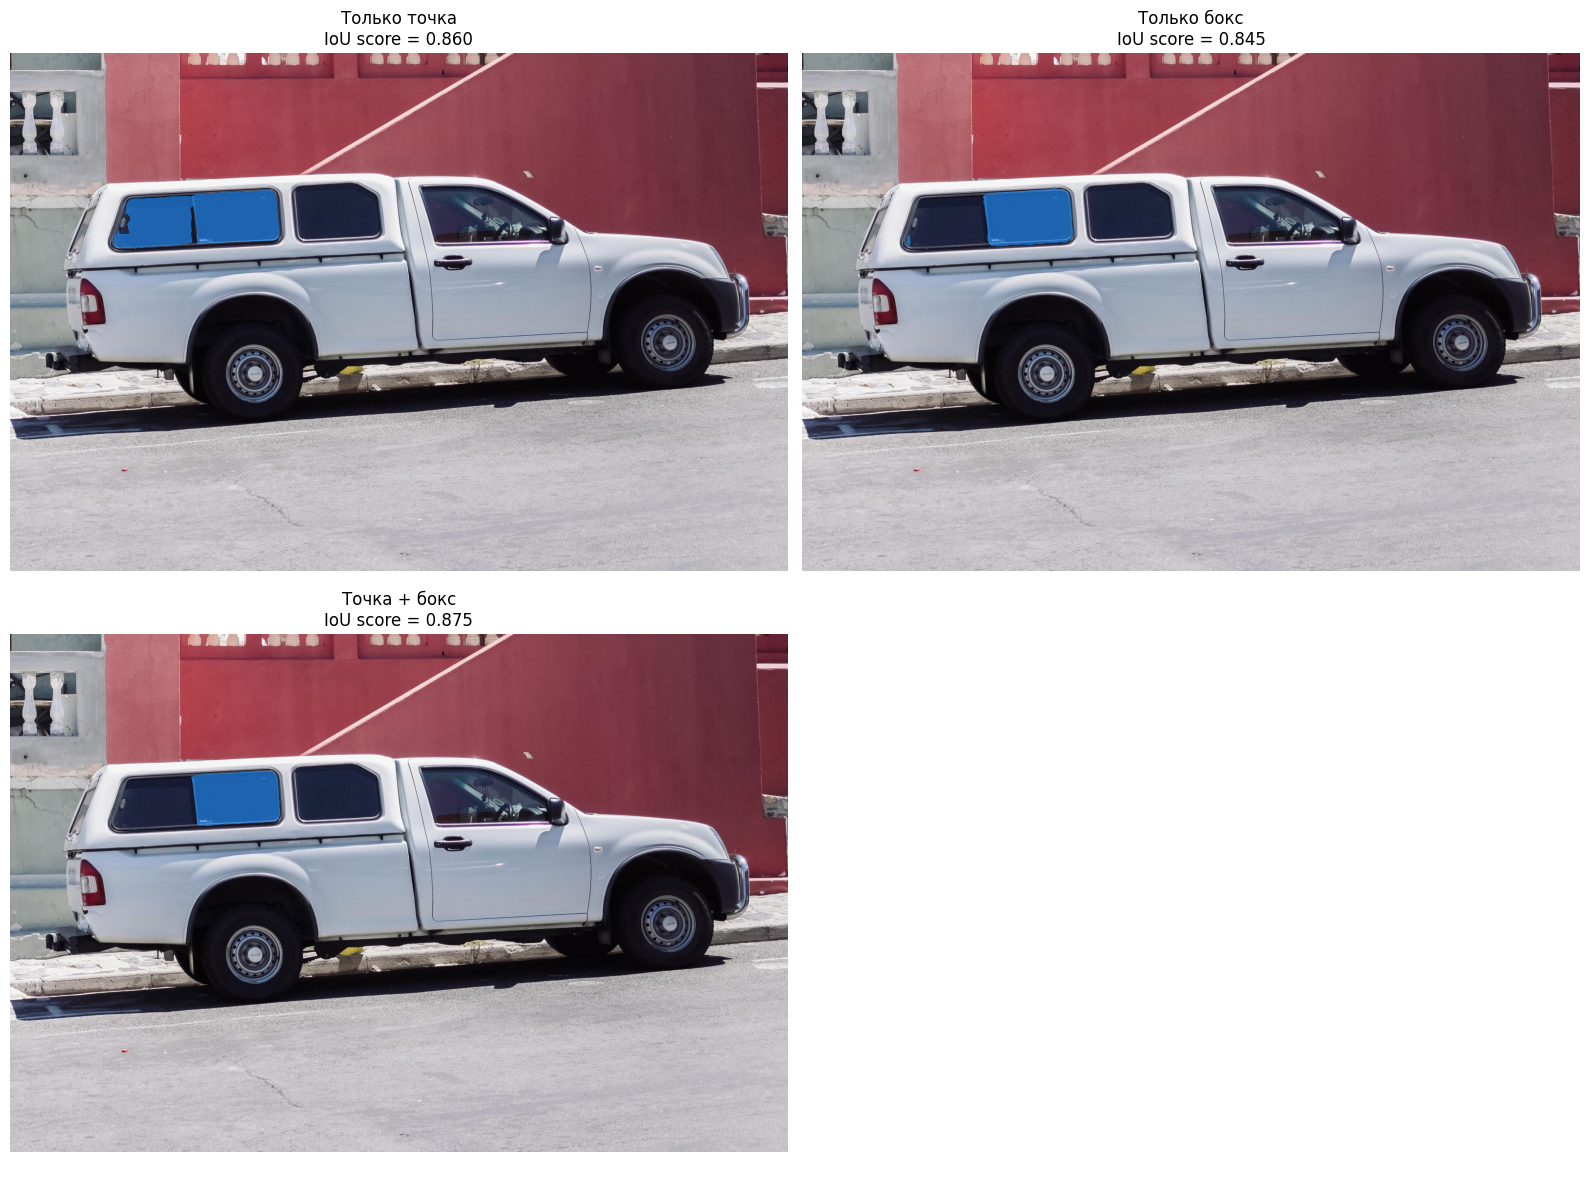

💡 Вывод: Комбинация промптов часто дает лучший результат!


In [31]:
# Сравним три подхода на одном объекте

# 1. Точка
point = np.array([[500, 375]])
masks_point, scores_point, _ = predictor.predict(
    point_coords=point, point_labels=np.array([1]), multimask_output=False
)

# 2. Бокс
box = np.array([350, 300, 700, 550])
masks_box, scores_box, _ = predictor.predict(
    box=box[None, :], multimask_output=False
)

# 3. Точка + бокс вместе!
masks_combined, scores_combined, _ = predictor.predict(
    point_coords=point,
    point_labels=np.array([1]),
    box=box[None, :],
    multimask_output=False
)

# Визуализация сравнения
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

methods = [
    ("Только точка", masks_point[0], scores_point[0]),
    ("Только бокс", masks_box[0], scores_box[0]),
    ("Точка + бокс", masks_combined[0], scores_combined[0]),
]

for idx, (title, mask, score) in enumerate(methods):
    ax = axes[idx // 2, idx % 2]
    ax.imshow(image)
    show_mask(mask, ax)
    ax.set_title(f"{title}\nIoU score = {score:.3f}", fontsize=12)
    ax.axis("off")

# Пустой subplot для красоты
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

print("💡 Вывод: Комбинация промптов часто дает лучший результат!")

## Домашнее Задание

**Задание 1: Интерактивный инструмент**

Создайте функцию, которая:
1. Принимает изображение и список точек (кликов пользователя)
2. Для каждой точки определяет, к какому объекту она относится
3. Возвращает:
   - Количество уникальных объектов, которые выделил пользователь
   - Общую площадь выделенных объектов
   - Визуализацию с разными цветами для каждого объекта

**Задание 2: Анализ качества**

1. Возьмите 3 разных изображения (природа, город, люди)
2. Для каждого изображения:
   - Запустите автоматическую сегментацию
   - Подсчитайте количество найденных объектов
   - Найдите средний IoU score
   - Сохраните статистику
3. Постройте график: "Тип изображения vs Количество объектов"
4. Сделайте вывод: на каких изображениях SAM работает лучше/хуже?

**Задание 3**

| Трек | Задание |
|------|---------|
| Creative** | Создайте "умное размытие фона": выделите главный объект точкой, размойте все остальное (эффект портретного режима) |
| Analytical | Реализуйте подсчет объектов определенного типа (например, "сколько машин на парковке") используя SAM + простые эвристики |
| Performance | Сравните скорость и качество трех моделей SAM: ViT-B, ViT-L, ViT-H. Постройте график "время vs качество" |


---

### Критерии оценки:
- Код работает без ошибок (20%)
- Правильное использование SAM API (30%)
- Качество визуализаций (20%)
- Глубина анализа и выводов (20%)
- Оформление и комментарии (10%)

### Формат сдачи:
- .ipynb файл с кодом и результатами
- 2-3 абзаца выводов
- Скриншоты результатов

## Полезные советы

### Частые проблемы:
1. CUDA out of memory → Используйте vit_b вместо vit_h, уменьшите `points_per_side`
2. Пустые маски → Проверьте, что точки/боксы внутри изображения
3. Медленная работа → Уменьшите `points_per_side` или используйте CPU для небольших изображений

### Ресурсы:
- [Официальный репозиторий SAM](https://github.com/facebookresearch/segment-anything)
[Demo SAM](https://segment-anything.com/demo) — попробуйте онлайн!
- [Paper SAM](https://arxiv.org/abs/2304.02643) — для тех, кто хочет понять internals
- [SA-1B Dataset](https://segment-anything.com/dataset/index.html) — 1.1 млрд масок!


In [13]:
# Домашняя работа: creative track

def load_local_image(path):
    return np.array(Image.open(path).convert("RGB"))


def smart_background_blur(image, point_xy, blur_kernel=(31, 31)):
    predictor.set_image(image)
    masks, scores, _ = predictor.predict(
        point_coords=np.array([point_xy]),
        point_labels=np.array([1]),
        multimask_output=True,
    )
    best_idx = int(np.argmax(scores))
    best_mask = masks[best_idx]

    blurred_background = cv2.GaussianBlur(image, blur_kernel, 0)
    result = blurred_background.copy()
    result[best_mask] = image[best_mask]
    return result, best_mask, float(scores[best_idx])


def show_blur_result(title, image, point_xy, result, mask, score):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(image)
    axes[0].scatter(point_xy[0], point_xy[1], c="blue", s=250, marker="*")
    axes[0].set_title(f"{title}: исходное изображение")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title(f"Маска\nscore={score:.3f}")
    axes[1].axis("off")

    axes[2].imshow(result)
    axes[2].set_title("Умное размытие фона")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

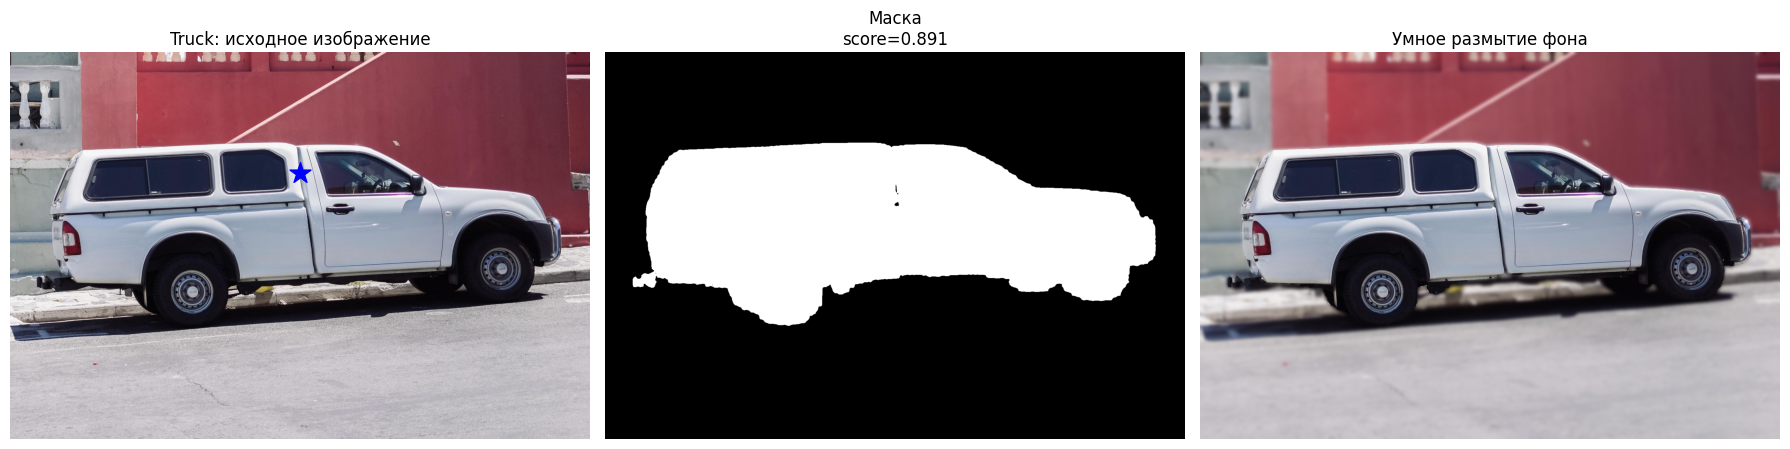

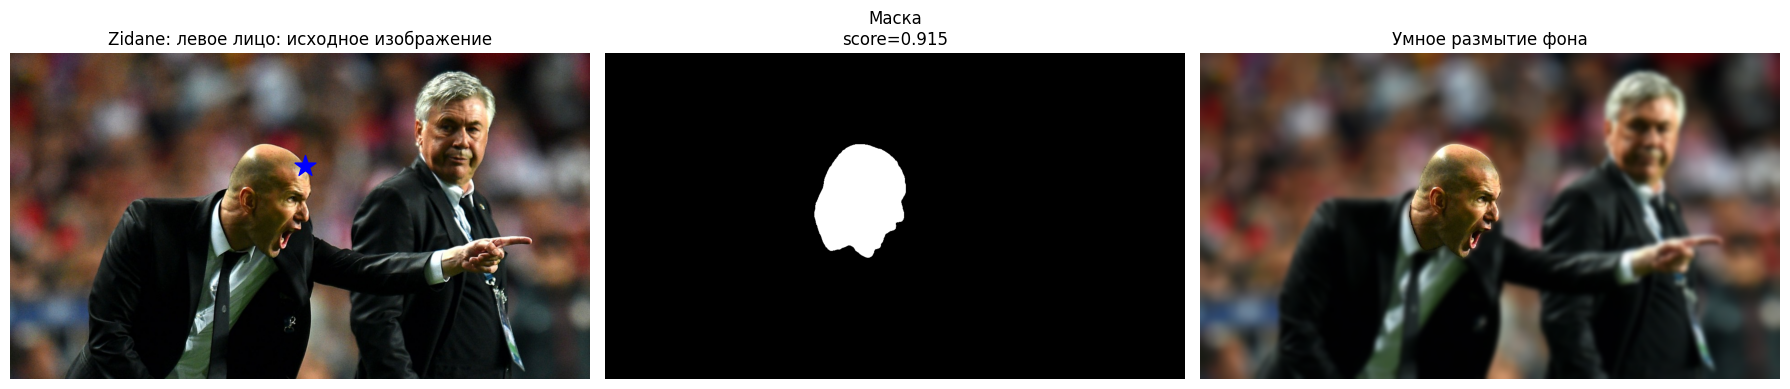

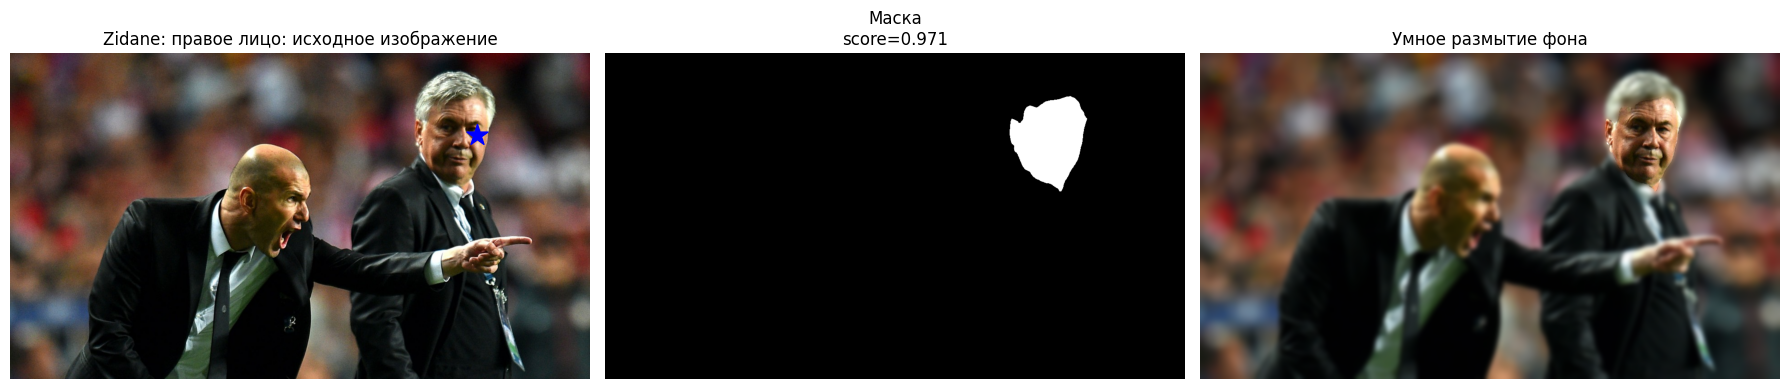

In [14]:
# Домашнее задание: blur на нескольких локальных изображениях
examples = [
    {
        "title": "Truck",
        "image": load_local_image("truck.jpg"),
        "point": np.array([900, 375]),
    },
    {
        "title": "Zidane: левое лицо",
        "image": load_local_image("zidane.jpg"),
        "point": np.array([650, 250]),
    },
    {
        "title": "Zidane: правое лицо",
        "image": load_local_image("zidane.jpg"),
        "point": np.array([1030, 180]),
    },
]

blur_summaries = []
for example in examples:
    result, mask, score = smart_background_blur(example["image"], example["point"])
    show_blur_result(
        example["title"],
        example["image"],
        example["point"],
        result,
        mask,
        score,
    )

### Выводы

Эффект умного размытия фона работает лучше всего, когда точка поставлена внутри крупного и хорошо отделимого объекта. На `truck.jpg` модель уверенно выделяет грузовик, а на `zidane.jpg` можно отдельно получить маску для каждого лица, просто меняя координаты клика.

Такой сценарий хорошо подходит для интерактивных приложений: пользователь делает один клик, SAM строит маску объекта, после чего фон можно размыть без дополнительной ручной разметки.